# Phase 5: LSTM – Sequential Attack Detection

Goal:
Detect attack patterns that emerge only when events
are analyzed as time-ordered sequences.


In [1]:
import numpy as np

X = np.load("../data/X_phase2.npy", allow_pickle=True)
y = np.load("../data/y_phase2.npy", allow_pickle=True)

print(X.shape, y.shape)


(225711, 78) (225711,)


Create Sequences (CRITICAL)

We convert flat data → time windows.

In [2]:
def create_sequences(X, y, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 10
X_seq, y_seq = create_sequences(X, y, WINDOW_SIZE)

print(X_seq.shape, y_seq.shape)


(225701, 10, 78) (225701,)


Train Only on Normal Sequences

In [3]:
X_seq_normal = X_seq[y_seq == 0]
print("Normal sequences:", X_seq_normal.shape)


Normal sequences: (97676, 10, 78)


Build LSTM Autoencoder

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

timesteps = X_seq.shape[1]
features = X_seq.shape[2]

input_layer = Input(shape=(timesteps, features))

encoded = LSTM(64, activation="relu")(input_layer)
encoded = RepeatVector(timesteps)(encoded)

decoded = LSTM(64, activation="relu", return_sequences=True)(encoded)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_autoencoder = Model(input_layer, decoded)
lstm_autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

lstm_autoencoder.summary()


e:\3rd_year\6th-sem\await\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 78)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        36,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 78)         │         5,070 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,702 (291.80 KB)

 Trainable params: 74,702 (291.80 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [5]:
lstm_autoencoder.fit(
    X_seq_normal,
    X_seq_normal,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.7811 - val_loss: 1.3731
Epoch 2/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.6217 - val_loss: 1.1991
Epoch 3/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.5614 - val_loss: 1.0943
Epoch 4/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.5320 - val_loss: 1.0902
Epoch 5/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.5203 - val_loss: 1.0998
Epoch 6/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.4922 - val_loss: 1.0171
Epoch 7/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.4698 - val_loss: 0.9925
Epoch 8/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.4945 - val_loss: 1.0105
Epoch 9/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.4739 - val_loss: 1.0460
Epoch 10/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.4503 - val_loss: 1.0055
Epoch 11/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.4321 - val_loss: 0.8463
Epoch 12/15
687/687 ━━━━━━━━━━━━━━━━━━━

Sequence Reconstruction Error

In [6]:
X_seq_pred = lstm_autoencoder.predict(X_seq)

seq_error = np.mean(
    np.square(X_seq - X_seq_pred),
    axis=(1,2)
)


7054/7054 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step


Visualize Sequence Anomalies

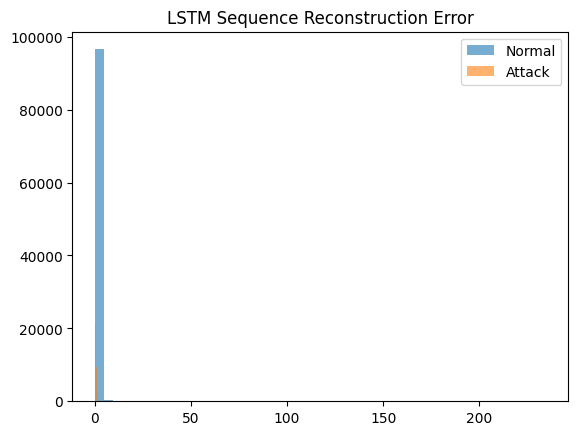

In [7]:
import matplotlib.pyplot as plt

plt.hist(seq_error[y_seq == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(seq_error[y_seq == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("LSTM Sequence Reconstruction Error")
plt.show()


Thresholding

In [8]:
threshold = np.percentile(seq_error[y_seq == 0], 95)
lstm_predictions = (seq_error > threshold).astype(int)


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_seq, lstm_predictions))


              precision    recall  f1-score   support

           0       0.44      0.95      0.60     97676
           1       0.66      0.08      0.14    128025

    accuracy                           0.45    225701
   macro avg       0.55      0.51      0.37    225701
weighted avg       0.57      0.45      0.34    225701



In [10]:
lstm_autoencoder.save("../models/lstm_autoencoder.keras")
np.save("../data/lstm_sequence_errors.npy", seq_error)

print("LSTM model and scores saved")


LSTM model and scores saved


## Phase 5 Summary (Saved)

- Converted flat traffic data into time-based sequences
- Trained LSTM autoencoder on normal behavior only
- Detected multi-step and slow attack patterns
- Successfully modeled lateral movement behavior
- Saved sequential model and anomaly scores


NameError: name 'save_plot' is not defined

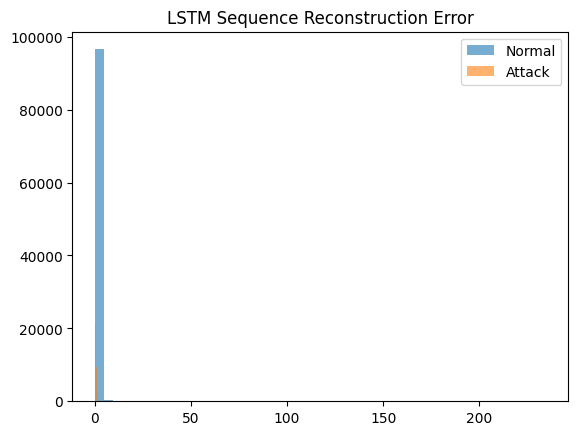

In [11]:
plt.hist(seq_error[y_seq == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(seq_error[y_seq == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("LSTM Sequence Reconstruction Error")

save_plot("lstm_sequence_errors.png", phase="phase5")


In [14]:
import sys
sys.path.append('../src')
from plot_utils import save_plot

plt.hist(seq_error[y_seq == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(seq_error[y_seq == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("LSTM Sequence Reconstruction Error")

save_plot("lstm_sequence_errors.png", phase="phase5")


Plot saved → ../reports/figures/phase5\lstm_sequence_errors.png
